# GSVA pathway bubble plots

Remote source reviewed from `20250604p38-afterYZ/GSVA/气泡.ipynb`. Run from top to bottom after configuring `config/paths.*`.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


正在从 msigdbr 加载基因集 (C5, C2, H)...
基因集加载成功！
正在根据通路ID构建基因列表...
!!! 警告：未能为通路找到任何基因: GO:0030097 
为 GO:0019221 找到 446 个基因。
为 GO:0043011 找到 20 个基因。
为 GO:0002318 找到 7 个基因。
为 GO:0034097 找到 853 个基因。
为 GO:0004896 找到 96 个基因。
为 GO:0043548 找到 27 个基因。
为 GO:0019955 找到 140 个基因。
为 GO:0006974 找到 794 个基因。
为 GO:0051301 找到 612 个基因。
为 GO:0045944 找到 1152 个基因。
为 GO:0006260 找到 279 个基因。
!!! 警告：未能为通路找到任何基因: GO:0045893 
为 GO:0007049 找到 1678 个基因。
为 GO:2001235 找到 126 个基因。
为 GO:0000122 找到 854 个基因。
!!! 警告：未能为通路找到任何基因: GO:0000086 
为 GO:0061484 找到 20 个基因。
为 GO:0048872 找到 278 个基因。
为 GO:0030099 找到 384 个基因。
为 GO:0000165 找到 754 个基因。
为 GO:0071425 找到 25 个基因。


Normalizing layer: counts



正在计算伪批量表达矩阵 (Seurat v5 模式)...


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
First group.by variable `celltype_condition` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.
ℹ GSVA version 2.0.0

! 938 genes with constant values throughout the samples

! Genes with constant values are discarded

ℹ Calculating GSVA ranks

ℹ GSVA dense (classical) algorithm

ℹ Row-wise ECDF estimation with Gaussian kernels

ℹ Calculating GSVA column ranks

ℹ Calculating GSVA scores

✔ Calculations finished



解析后的唯一细胞类型: 0 Mzb1+ pDC, 1 Iglc3+ pDC, 12 pre-pDC, 2 DC progenitor, 4 CD115+ CDP, 7 CD115- CDP 
用于绘图的有序细胞类型: 2 DC progenitor, 4 CD115+ CDP, 7 CD115- CDP, 12 pre-pDC, 0 Mzb1+ pDC, 1 Iglc3+ pDC 
使用 Patchwork 组合图形...


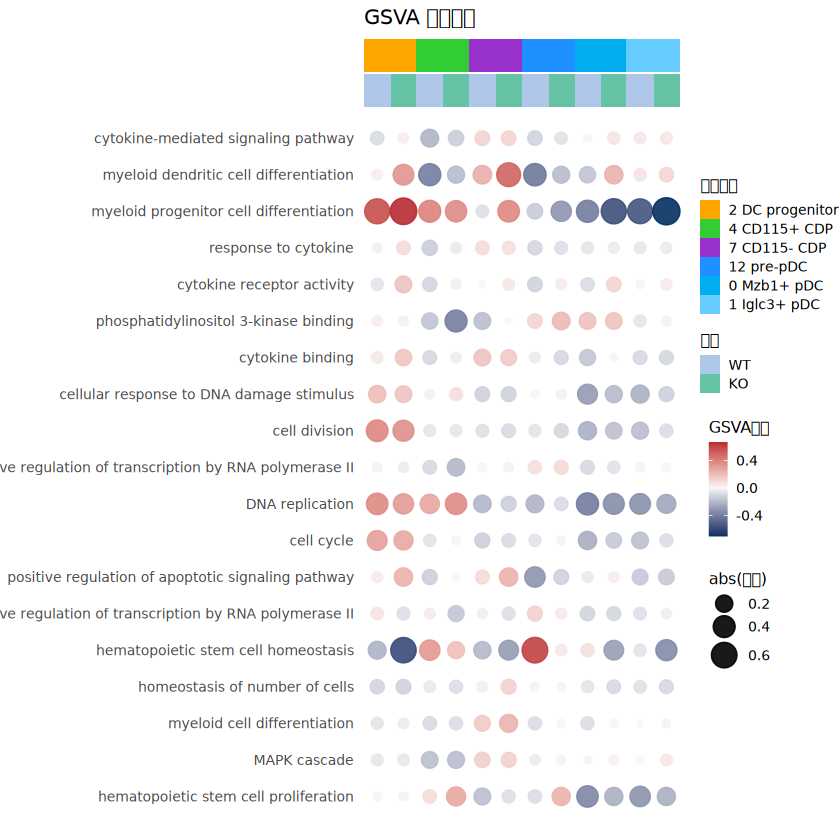

In [ ]:
# --------------------------------------------------------------------------
# |                        GSVA 分析与可视化脚本 (已适配 Seurat v5)           |
# |                                                                        |
# | 核心逻辑：                                                             |
# | 1. 修正了 AverageExpression 调用方式以兼容 Seurat v5 的 Assay5 结构。 |
# | 2. 保留了您验证过的、带回退逻辑的 for 循环来精确查找基因集。           |
# | 3. 生成您最初要求的、基于 ggplot 和 patchwork 的点状热图。              |
# --------------------------------------------------------------------------

# 加载必要的 R 包
suppressPackageStartupMessages({
    library(GSVA)
    library(msigdbr)
    library(Seurat)
    library(dplyr)
    library(tibble)
    library(tidyr)
    library(ggplot2)
    library(patchwork)
    library(Cairo)
})

# --- 1. 数据加载与准备 ---
seu <- readRDS(legacy_path("20250604p38-afterYZ/anno.rds"))
mac_clusters_original <- c(
  "2 DC progenitor", "4 CD115+ CDP", "7 CD115- CDP",
  "12 pre-pDC", "0 Mzb1+ pDC", "1 Iglc3+ pDC"
)
mac_cells <- subset(seu, subset = celltype %in% mac_clusters_original)
mac_cells$celltype_condition <- paste(mac_cells$celltype, mac_cells$orig.ident, sep = "-")
Idents(mac_cells) <- "celltype_condition"

# --- 2. 定义通路ID和对应的显示名称 ---
GenesetsOfInterest_ids <- c(
  "GO:0030097", "GO:0019221", "GO:0043011", "GO:0002318", "GO:0034097",
  "GO:0004896", "GO:0043548", "GO:0019955", "GO:0006974", "GO:0051301",
  "GO:0045944", "GO:0006260", "GO:0045893", "GO:0007049", "GO:2001235",
  "GO:0000122", "GO:0000086", "GO:0061484", "GO:0048872", "GO:0030099",
  "GO:0000165", "GO:0071425"
)
GenesetsOfInterest_ids <- unique(GenesetsOfInterest_ids)
go_to_description_map <- c(
  "GO:0030097" = "hemopoiesis",
  "GO:0019221" = "cytokine-mediated signaling pathway",
  "GO:0043011" = "myeloid dendritic cell differentiation",
  "GO:0002318" = "myeloid progenitor cell differentiation",
  "GO:0034097" = "response to cytokine",
  "GO:0004896" = "cytokine receptor activity",
  "GO:0043548" = "phosphatidylinositol 3-kinase binding",
  "GO:0019955" = "cytokine binding",
  "GO:0006974" = "cellular response to DNA damage stimulus",
  "GO:0051301" = "cell division",
  "GO:0045944" = "positive regulation of transcription by RNA polymerase II",
  "GO:0006260" = "DNA replication",
  "GO:0045893" = "positive regulation of DNA-templated transcription",
  "GO:0007049" = "cell cycle",
  "GO:2001235" = "positive regulation of apoptotic signaling pathway",
  "GO:0000122" = "negative regulation of transcription by RNA polymerase II",
  "GO:0000086" = "G2/M transition of mitotic cell cycle",
  "GO:0061484" = "hematopoietic stem cell homeostasis",
  "GO:0048872" = "homeostasis of number of cells",
  "GO:0030099" = "myeloid cell differentiation",
  "GO:0000165" = "MAPK cascade",
  "GO:0071425" = "hematopoietic stem cell proliferation"
)

# --- 3. 加载基因集 (采用您验证过的成功方法) ---
cat("正在从 msigdbr 加载基因集 (C5, C2, H)...\n")
c5_all <- msigdbr(species = "Mus musculus", category = "C5") 
c2 <- msigdbr(species = "Mus musculus", category = "C2") 
h <- msigdbr(species = "Mus musculus", category = "H")
gs2gene <- rbind(c2, c5_all, h)
cat("基因集加载成功！\n")

# --- 4. 构建基因集列表 (采用您验证过的、带回退逻辑的成功方法) ---
GenesetsOfInterest.list <- list()
cat("正在根据通路ID构建基因列表...\n")
for (gs in GenesetsOfInterest_ids) {
  glist <- unique((gs2gene %>% dplyr::filter(gs_exact_source == gs))$gene_symbol)
  if (length(glist) == 0) {
    glist <- unique((gs2gene %>% dplyr::filter(gs_name == gs))$gene_symbol)
  }
  
  if(length(glist) > 0) {
    GenesetsOfInterest.list[[gs]] <- glist
    cat("为", gs, "找到", length(glist), "个基因。\n")
  } else {
    cat("!!! 警告：未能为通路找到任何基因:", gs, "\n")
  }
}
if (length(GenesetsOfInterest.list) == 0) { stop("错误：未能成功加载任何指定的基因集。") }


# --- 5. 运行 GSVA 分析 ---
DefaultAssay(mac_cells) <- "RNA"

# 标准化数据 (这是Seurat v5的推荐做法)
mac_cells <- NormalizeData(mac_cells)

# ========================【Seurat v5 关键修正】========================
# 在 Seurat v5 中，AverageExpression 不再使用 slot = "data"，
# 而是使用 layer = "data" 来访问标准化后的数据。
cat("正在计算伪批量表达矩阵 (Seurat v5 模式)...\n")
mac_cells.bulk <- AverageExpression(mac_cells, assays = "RNA", layer = "data", group.by = "celltype_condition")
# =====================================================================

expr_matrix <- as.matrix(mac_cells.bulk$RNA)

# 创建 GSVA 参数对象并运行
param <- gsvaParam(expr = expr_matrix, geneSets = GenesetsOfInterest.list, kcdf = "Gaussian")
mac_cells.bulk.gsva <- gsva(param, verbose = TRUE) 

# --- 6. 准备绘图数据 (后续流程不变) ---
final_pathways_in_gsva <- intersect(names(GenesetsOfInterest.list), rownames(mac_cells.bulk.gsva))
ordered_final_pathways_ids <- GenesetsOfInterest_ids[GenesetsOfInterest_ids %in% final_pathways_in_gsva]
gsva_matrix <- mac_cells.bulk.gsva[ordered_final_pathways_ids, , drop = FALSE]

columns <- colnames(gsva_matrix) 

celltype_annotations <- character(length(columns)); condition_annotations <- character(length(columns))
condition_pattern <- "(WT|KO)$"
for (i in 1:length(columns)) {
  col_name <- sub("^g", "", columns[i]) # 去掉 'g' 前缀
  if (grepl(condition_pattern, col_name)) {
    condition_annotations[i] <- regmatches(col_name, regexpr(condition_pattern, col_name))
    celltype_annotations[i] <- sub(paste0("-?", condition_annotations[i], "$"), "", col_name)
  } else { 
      condition_annotations[i] <- "Unknown"; celltype_annotations[i] <- col_name; 
      warning(paste("无法解析:", columns[i])) 
  }
}
celltype_annotations <- trimws(celltype_annotations); condition_annotations <- trimws(condition_annotations)
unique_celltypes_parsed <- unique(celltype_annotations)
cat("解析后的唯一细胞类型:", paste(unique_celltypes_parsed, collapse=", "), "\n")
ordered_celltypes_for_plotting <- mac_clusters_original[mac_clusters_original %in% unique_celltypes_parsed]
cat("用于绘图的有序细胞类型:", paste(ordered_celltypes_for_plotting, collapse=", "), "\n")
condition_order <- c("WT", "KO")

annotation_col <- data.frame(
  Sample = factor(columns, levels = columns[order(factor(celltype_annotations, levels=ordered_celltypes_for_plotting), factor(condition_annotations, levels=condition_order))]),
  Celltype = factor(celltype_annotations, levels = ordered_celltypes_for_plotting),
  Condition = factor(condition_annotations, levels = condition_order),
  row.names = columns, stringsAsFactors = FALSE
)
ordered_samples <- levels(annotation_col$Sample)

gsva_long <- as.data.frame(gsva_matrix[, ordered_samples, drop = FALSE]) %>%
  rownames_to_column("Pathway_ID") %>%
  pivot_longer(cols = -Pathway_ID, names_to = "Sample", values_to = "GSVA_Score") %>%
  left_join(annotation_col %>% select(Sample, Celltype, Condition), by = "Sample") %>%
  mutate(Pathway_Name = go_to_description_map[Pathway_ID], Sample = factor(Sample, levels = ordered_samples))
gsva_long$Pathway_Name[is.na(gsva_long$Pathway_Name)] <- gsva_long$Pathway_ID[is.na(gsva_long$Pathway_Name)]
gsva_long <- gsva_long %>% filter(!is.na(Celltype) & !is.na(Condition))
pathway_display_levels <- go_to_description_map[ordered_final_pathways_ids]
pathway_display_levels <- pathway_display_levels[!is.na(pathway_display_levels)]
gsva_long$Pathway_Name <- factor(gsva_long$Pathway_Name, levels = rev(pathway_display_levels))

# --- 7. 绘图 ---
celltype_colors <- c("2 DC progenitor" = "#FFA500", "4 CD115+ CDP" = "#32CD32", "7 CD115- CDP" = "#9932CC", "12 pre-pDC" = "#1E90FF", "0 Mzb1+ pDC" = "#00AEEF", "1 Iglc3+ pDC" = "#66CCFF")
available_celltype_colors <- celltype_colors[names(celltype_colors) %in% levels(annotation_col$Celltype)]
condition_colors <- c("WT" = "#AEC7E8", "KO" = "#66C2A5")
available_condition_colors <- condition_colors[names(condition_colors) %in% levels(annotation_col$Condition)]

p_main <- ggplot(gsva_long, aes(x = Sample, y = Pathway_Name)) +
  geom_point(aes(color = GSVA_Score, size = abs(GSVA_Score)), alpha = 0.9) +
  # English legend titles
  scale_color_gradient2(
      low = "#053061", mid = "#F7F7F7", high = "#B2182B", 
      midpoint = 0, name = "GSVA Score"
  ) +
  scale_size_continuous(range = c(1, 7), name = "abs(Score)") +
  
  labs(x = NULL, y = NULL) + 
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x = element_blank(), 
    axis.ticks.x = element_blank(), 
    axis.text.y = element_text(size = 8), 
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(), 
    legend.title = element_text(size=9, face = "bold"), # Use bold for titles
    legend.text = element_text(size=8), 
    legend.key.size = unit(0.4, "cm")
  )

# --- Celltype Annotation Plot (p_annot_celltype) ---
p_annot_celltype <- ggplot(annotation_col, aes(x = Sample, y = 1)) +
  geom_tile(aes(fill = Celltype)) +
  # English legend title
  scale_fill_manual(values = available_celltype_colors, name = "Cell Type") +
  theme_void() + 
  theme(
    legend.position = "left", 
    legend.title = element_text(size=9, face = "bold"), 
    legend.text = element_text(size=8), 
    legend.key.size = unit(0.4, "cm")
  )

# --- Condition Annotation Plot (p_annot_condition) ---
p_annot_condition <- ggplot(annotation_col, aes(x = Sample, y = 1)) +
  geom_tile(aes(fill = Condition)) +
  # English legend title
  scale_fill_manual(values = available_condition_colors, name = "Condition") +
  theme_void() + 
  theme(
    legend.position = "left", 
    legend.title = element_text(size=9, face = "bold"), 
    legend.text = element_text(size=8), 
    legend.key.size = unit(0.4, "cm")
  )

# --- Combine plots with patchwork ---
cat("Combining plots using patchwork...\n")

combined_plot <- p_annot_celltype / p_annot_condition / p_main +
    plot_layout(heights = c(1, 1, 20), guides = 'collect') +
    # English main title
    plot_annotation(title = 'GSVA Score Comparison') &
    theme(
      plot.title = element_text(hjust = 0.5, size=14, face="bold"), 
      legend.position = 'right'
    )

options(repr.plot.width = 20, repr.plot.height = 10)
print(combined_plot)

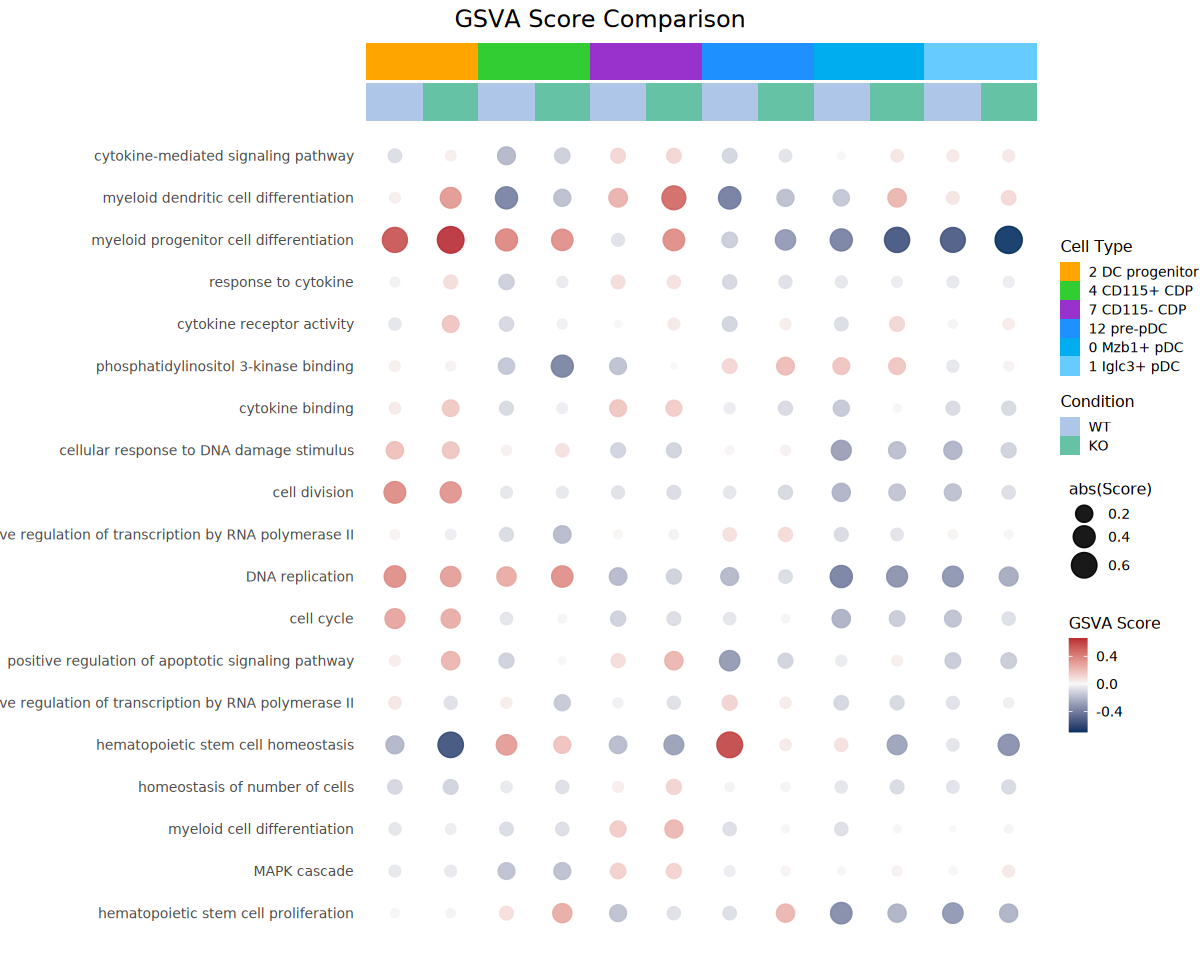

In [3]:
p_main <- ggplot(gsva_long, aes(x = Sample, y = Pathway_Name)) +
  geom_point(aes(color = GSVA_Score, size = abs(GSVA_Score)), alpha = 0.9) +
  # English legend titles
  scale_color_gradient2(
      low = "#053061", mid = "#F7F7F7", high = "#B2182B", 
      midpoint = 0, name = "GSVA Score"
  ) +
  scale_size_continuous(range = c(1, 7), name = "abs(Score)") +
  
  labs(x = NULL, y = NULL) + 
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x = element_blank(), 
    axis.ticks.x = element_blank(), 
    axis.text.y = element_text(size = 8), 
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(), 
    legend.title = element_text(size=9, face = "bold"), # Use bold for titles
    legend.text = element_text(size=8), 
    legend.key.size = unit(0.4, "cm")
  )

# --- Celltype Annotation Plot (p_annot_celltype) ---
p_annot_celltype <- ggplot(annotation_col, aes(x = Sample, y = 1)) +
  geom_tile(aes(fill = Celltype)) +
  # English legend title
  scale_fill_manual(values = available_celltype_colors, name = "Cell Type") +
  theme_void() + 
  theme(
    legend.position = "left", 
    legend.title = element_text(size=9, face = "bold"), 
    legend.text = element_text(size=8), 
    legend.key.size = unit(0.4, "cm")
  )

# --- Condition Annotation Plot (p_annot_condition) ---
p_annot_condition <- ggplot(annotation_col, aes(x = Sample, y = 1)) +
  geom_tile(aes(fill = Condition)) +
  # English legend title
  scale_fill_manual(values = available_condition_colors, name = "Condition") +
  theme_void() + 
  theme(
    legend.position = "left", 
    legend.title = element_text(size=9, face = "bold"), 
    legend.text = element_text(size=8), 
    legend.key.size = unit(0.4, "cm")
  )

combined_plot <- p_annot_celltype / p_annot_condition / p_main +
    plot_layout(heights = c(1, 1, 20), guides = 'collect') +
    # English main title
    plot_annotation(title = 'GSVA Score Comparison') &
    theme(
      plot.title = element_text(hjust = 0.5, size=14, face="bold"), 
      legend.position = 'right'
    )

options(repr.plot.width = 10, repr.plot.height = 8)
print(combined_plot)

Combining plots using patchwork...


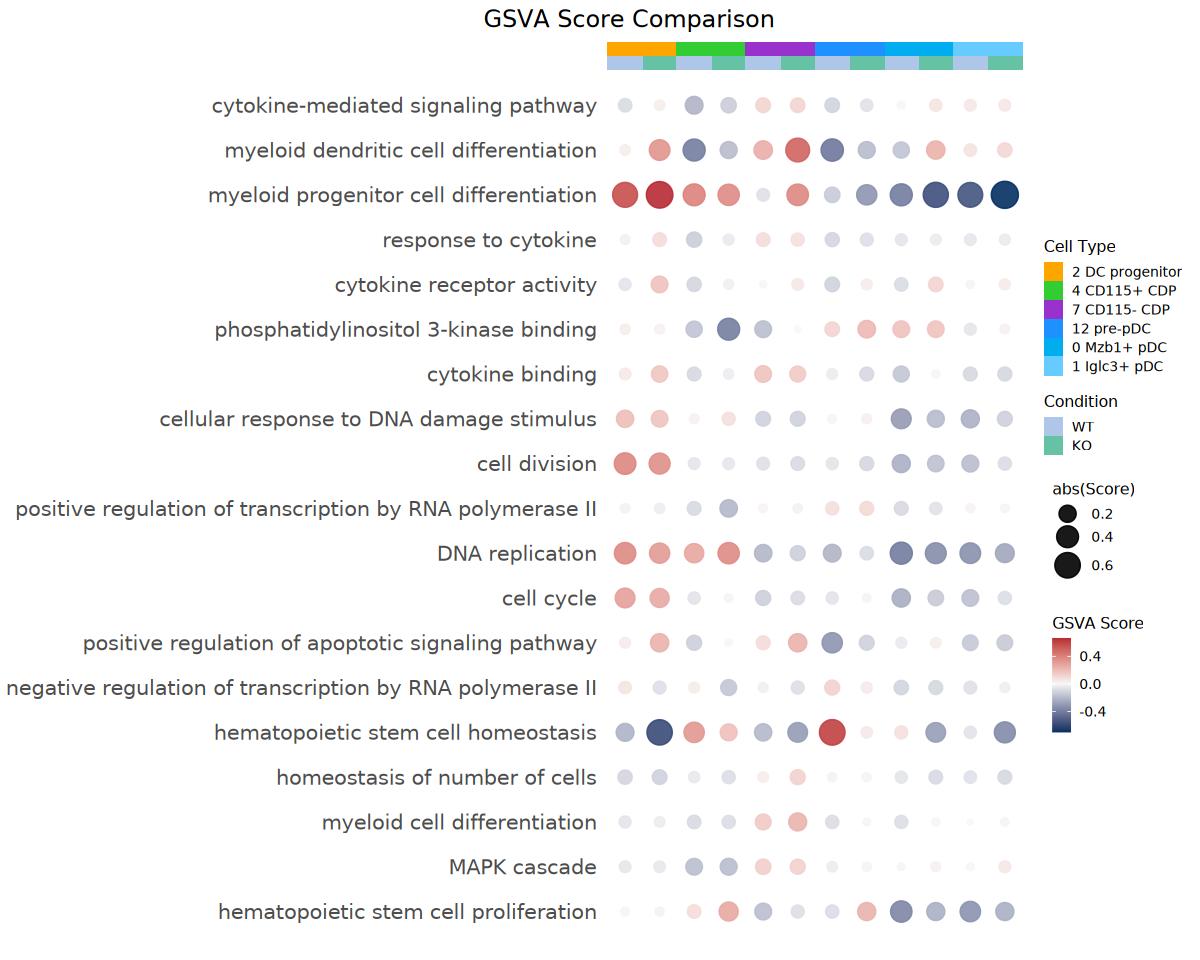

In [19]:
# --------------------------------------------------------------------------
# |                        7. 绘图 (英文图表，中文注释)                      |
# --------------------------------------------------------------------------

# --- 定义颜色 ---
# 定义细胞类型的颜色
celltype_colors <- c(
    "2 DC progenitor" = "#FFA500", 
    "4 CD115+ CDP" = "#32CD32", 
    "7 CD115- CDP" = "#9932CC", 
    "12 pre-pDC" = "#1E90FF", 
    "0 Mzb1+ pDC" = "#00AEEF", 
    "1 Iglc3+ pDC" = "#66CCFF"
)
# 仅保留数据中实际存在的细胞类型的颜色
available_celltype_colors <- celltype_colors[names(celltype_colors) %in% levels(annotation_col$Celltype)]

# 定义分组 (Condition) 的颜色
condition_colors <- c("WT" = "#AEC7E8", "KO" = "#66C2A5")
available_condition_colors <- condition_colors[names(condition_colors) %in% levels(annotation_col$Condition)]


# --- 主图 (p_main): 即点图部分 ---
p_main <- ggplot(gsva_long, aes(x = Sample, y = Pathway_Name)) +
  # 使用点来表示GSVA分数，点的大小和颜色都与分数相关
  geom_point(aes(color = GSVA_Score, size = abs(GSVA_Score)), alpha = 0.9) +
  
  # 设置点的颜色映射：一个从蓝到白再到红的渐变，以0为中心
  scale_color_gradient2(
      low = "#053061", mid = "#F7F7F7", high = "#B2182B", 
      midpoint = 0, name = "GSVA Score" # 图例标题
  ) +
  # 设置点的大小范围
  scale_size_continuous(range = c(1, 7), name = "abs(Score)") +
  
  # 设置坐标轴标题 (这里我们不需要，所以设为NULL)
  labs(x = NULL, y = NULL) + 
  
  # 使用一个简洁的主题
  theme_minimal(base_size = 10) +
  
  # 对主题进行微调
  theme(
    # X轴相关设置: 隐藏文本标签和刻度线
    axis.text.x = element_blank(), 
    axis.ticks.x = element_blank(), 
    
    # Y轴相关设置: 设置通路名称的字体大小
    axis.text.y = element_text(size = 12), 
    
    # 面板网格线设置: 隐藏所有网格线，使背景更干净
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(), 
    
    # 图例相关设置
    legend.title = element_text(size=9, face = "bold"), # 图例标题字体
    legend.text = element_text(size=8),                 # 图例文字字体
    legend.key.size = unit(0.4, "cm"),                  # 图例色块大小

    # ========================= 【左右边距调整参数】 =========================
    # plot.margin 用于控制整个图表区域距离画布边缘的距离。
    # margin(top, right, bottom, left)
    # 增加 left 的值可以为左侧长通路名称留出更多空间。
    # 增加 right 的值可以为右侧图例或空白区域留出更多空间。
    plot.margin = margin(t = 5, r = 15, b = 5, l = 50, unit = "pt") # 单位可以是 "pt", "cm" 等
    # =====================================================================
  )

# --- 细胞类型注释条 (p_annot_celltype) ---
p_annot_celltype <- ggplot(annotation_col, aes(x = Sample, y = 1)) +
  # 使用瓦片图 (tile) 来创建色块
  geom_tile(aes(fill = Celltype)) +
  # 手动指定填充颜色和图例标题
  scale_fill_manual(values = available_celltype_colors, name = "Cell Type") +
  # 使用一个完全空白的主题，因为它只是一个色块条
  theme_void() + 
  # 调整这个色块条的图例 (虽然最终会被 patchwork 统一收集)
  theme(
    legend.position = "left", 
    legend.title = element_text(size=9, face = "bold"), 
    legend.text = element_text(size=8), 
    legend.key.size = unit(0.4, "cm")
  )

# --- 分组注释条 (p_annot_condition) ---
p_annot_condition <- ggplot(annotation_col, aes(x = Sample, y = 1)) +
  geom_tile(aes(fill = Condition)) +
  scale_fill_manual(values = available_condition_colors, name = "Condition") +
  theme_void() + 
  theme(
    legend.position = "left", 
    legend.title = element_text(size=9, face = "bold"), 
    legend.text = element_text(size=8), 
    legend.key.size = unit(0.4, "cm")
  )

# --- 使用 patchwork 组合图形 ---
cat("Combining plots using patchwork...\n")

combined_plot <- p_annot_celltype / p_annot_condition / p_main +
    # ========================= 【上下高度调整参数】 =========================
    # plot_layout 控制子图的布局。
    # heights 参数是一个向量，定义了每个子图的相对高度。
    # 这里的 c(1, 1, 20) 意味着：
    # - 第一个图 (p_annot_celltype) 的高度是 1 份
    # - 第二个图 (p_annot_condition) 的高度是 1 份
    # - 第三个图 (p_main) 的高度是 20 份
    # 减小前两个数字 (例如 c(0.5, 0.5, 20)) 可以让顶部的色块条变得更窄。
    # 增加前两个数字 (例如 c(2, 2, 20)) 可以让它们变得更宽。
    plot_layout(heights = c(0.5, 0.5, 30), guides = 'collect') +
    # ======================================================================
    
    # 添加一个总标题
    plot_annotation(title = 'GSVA Score Comparison') &
    
    # `&` 符号表示将后面的主题应用到所有子图中
    theme(
      # 总标题的样式
      plot.title = element_text(hjust = 0.5, size=14, face="bold"), 
      # 将所有图例统一收集到右侧
      legend.position = 'right'
    )

# 设置最终输出图片的尺寸 (在 R Notebook 或某些环境中生效)
options(repr.plot.width = 10, repr.plot.height = 8)

# 打印最终的组合图
print(combined_plot)

In [ ]:
output_filename <- legacy_path("0-0427mmp9出图修改/4mac/GSVA.pdf") 

ggsave(filename = output_filename,
       plot = combined_plot,    
       width = 12,
       height = 8,
       units = "in",
       dpi = 300
      )